# Assignment 1: Market Clearing (System Perspective)

### Import external libraries

In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from network import initialize_network, system_demand

## Step 0: Build a Relevant Case Study

Please select an electric power network from the following options:
1. IEEE 24-bus reliability test system: link.
2. IEEE reliability test system (2019 update): link.
3. IEEE power systems test cases (various cases with 14, 30, 57, 118, and 300 buses): link.
4. Case studies available in the open-source Julia platform PowerModels.jl: link.

You are also free to choose another case study. If some data is missing, please select reason-
able arbitrary values. For technical details on conventional generators and transmission lines, this link may be helpful (it corresponds to the IEEE 24-bus case study, but similar data can be used for other cases). 


### IEEE 24-bus reliability test system

In [2]:
# Intialise the network
consumers, generators = initialize_network()
print(generators)
print(consumers)
print("Network initialized successfully.")

[Generator(unit=1, node=1), Generator(unit=2, node=2), Generator(unit=3, node=7), Generator(unit=4, node=13), Generator(unit=5, node=15), Generator(unit=6, node=15), Generator(unit=7, node=16), Generator(unit=8, node=18), Generator(unit=9, node=21), Generator(unit=10, node=22), Generator(unit=11, node=23), Generator(unit=12, node=23), Generator(unit=13, node=3), Generator(unit=14, node=5), Generator(unit=15, node=7), Generator(unit=16, node=16), Generator(unit=17, node=21), Generator(unit=18, node=23)]
[Consumer(load=1, node=1, share=0.038), Consumer(load=2, node=2, share=0.034), Consumer(load=3, node=3, share=0.063), Consumer(load=4, node=4, share=0.026), Consumer(load=5, node=5, share=0.025), Consumer(load=6, node=6, share=0.048), Consumer(load=7, node=7, share=0.044), Consumer(load=8, node=8, share=0.06), Consumer(load=9, node=9, share=0.061), Consumer(load=10, node=10, share=0.068), Consumer(load=11, node=13, share=0.093), Consumer(load=12, node=14, share=0.068), Consumer(load=13, 

In [3]:
# Define the demand at 16:00
total_consumption_16 = system_demand[16]
print(f"Total consumption at 16:00 is {total_consumption_16} MW")

# define the demand at each node at 16:00
# Indexed so that 1st consumer is 1 to match network definition
consumer_demands_16 = {i+1: system_demand[16]*consumers[i].share for i in range(len(consumers))}
print("Consumer demands at 16:00:", consumer_demands_16)



Total consumption at 16:00 is 2464.965 MW
Consumer demands at 16:00: {1: 93.66867, 2: 83.80881000000001, 3: 155.292795, 4: 64.08909, 5: 61.62412500000001, 6: 118.31832000000001, 7: 108.45846, 8: 147.8979, 9: 150.362865, 10: 167.61762000000002, 11: 229.241745, 12: 167.61762000000002, 13: 273.61111500000004, 14: 86.27377500000001, 15: 288.400905, 16: 157.75776000000002, 17: 110.92342500000001}


In [4]:
# Define the Supply at 16:00
# Indexed so that first generator is 1
generator_capacity = {i+1: generators[i].p_max for i in range(len(generators))}
print("Generator capacities:", generator_capacity)

Generator capacities: {1: 152, 2: 152, 3: 350, 4: 591, 5: 60, 6: 155, 7: 155, 8: 400, 9: 400, 10: 300, 11: 310, 12: 350, 13: 200, 14: 200, 15: 200, 16: 200, 17: 200, 18: 200}


## Step 2 – Step 3: Network Constraints

In [5]:
# Create the optimization model
nodal_model = gp.Model("Optimization_Step_3")

Set parameter Username
Set parameter LicenseID to value 2773996
Academic license - for non-commercial use only - expires 2027-02-02


In [6]:
# Add Production & Consumption Variables

# Production Variables
production_variables = {g.unit_id: nodal_model.addVar(lb = 0, ub = float('inf'), vtype=GRB.CONTINUOUS, name = f"p_g_{g.unit_id}") for g in generators}
nodal_model.update()
print("Production Variables check:\n", production_variables)

# Consumption Variables
consumption_variables = {c.load_id: nodal_model.addVar(lb = 0, ub = consumer_demands_16[c.load_id], vtype=GRB.CONTINUOUS, name = f"p_d_{c.load_id}") for c in consumers}
nodal_model.update()
print("Consumption Variables check:\n", consumption_variables)

Production Variables check:
 {1: <gurobi.Var p_g_1>, 2: <gurobi.Var p_g_2>, 3: <gurobi.Var p_g_3>, 4: <gurobi.Var p_g_4>, 5: <gurobi.Var p_g_5>, 6: <gurobi.Var p_g_6>, 7: <gurobi.Var p_g_7>, 8: <gurobi.Var p_g_8>, 9: <gurobi.Var p_g_9>, 10: <gurobi.Var p_g_10>, 11: <gurobi.Var p_g_11>, 12: <gurobi.Var p_g_12>, 13: <gurobi.Var p_g_13>, 14: <gurobi.Var p_g_14>, 15: <gurobi.Var p_g_15>, 16: <gurobi.Var p_g_16>, 17: <gurobi.Var p_g_17>, 18: <gurobi.Var p_g_18>}
Consumption Variables check:
 {1: <gurobi.Var p_d_1>, 2: <gurobi.Var p_d_2>, 3: <gurobi.Var p_d_3>, 4: <gurobi.Var p_d_4>, 5: <gurobi.Var p_d_5>, 6: <gurobi.Var p_d_6>, 7: <gurobi.Var p_d_7>, 8: <gurobi.Var p_d_8>, 9: <gurobi.Var p_d_9>, 10: <gurobi.Var p_d_10>, 11: <gurobi.Var p_d_11>, 12: <gurobi.Var p_d_12>, 13: <gurobi.Var p_d_13>, 14: <gurobi.Var p_d_14>, 15: <gurobi.Var p_d_15>, 16: <gurobi.Var p_d_16>, 17: <gurobi.Var p_d_17>}


In [7]:
# Add Transmission Variables

# Nodes are indexed from 1 to 24 in the network definition, so we create variables for each node
N = list(range(1, 25))

# Creates variables theta[1]...theta[24] for each node, with no bounds (can be positive or negative)
theta_variables = nodal_model.addVars(N, lb=-GRB.INFINITY, ub=GRB.INFINITY, name=f"theta")

# Slack bus (given in the RTS-24 doc: slack bus is node 13)
ref_bus = 13
nodal_model.addConstr(theta_variables[ref_bus] == 0, name="ref_angle")

# Print the theta variables to check they have been created correctly
nodal_model.update()
print("Theta Variables check:\n", theta_variables)

# Vector of lines were added to network
from network import LINES
L = range(len(LINES)) 
print ("Line indices check:\n", L) # 34 transmission lines in the network

# Susceptance values for all lines as given in the assignment brief
B = 500.0

# Create generator at node mapping for constraints
gen_at_node = {
    n: gp.quicksum(production_variables[g.unit_id] for g in generators if g.node == n)
    for n in N
}
print("Generator at node mapping check:\n", gen_at_node)

# Create load at node mapping for constraints
load_at_node = {
    n: gp.quicksum(consumption_variables[c.load_id] for c in consumers if c.node == n)
    for n in N
}
print("Load at node mapping check:\n", load_at_node)

Theta Variables check:
 {1: <gurobi.Var theta[1]>, 2: <gurobi.Var theta[2]>, 3: <gurobi.Var theta[3]>, 4: <gurobi.Var theta[4]>, 5: <gurobi.Var theta[5]>, 6: <gurobi.Var theta[6]>, 7: <gurobi.Var theta[7]>, 8: <gurobi.Var theta[8]>, 9: <gurobi.Var theta[9]>, 10: <gurobi.Var theta[10]>, 11: <gurobi.Var theta[11]>, 12: <gurobi.Var theta[12]>, 13: <gurobi.Var theta[13]>, 14: <gurobi.Var theta[14]>, 15: <gurobi.Var theta[15]>, 16: <gurobi.Var theta[16]>, 17: <gurobi.Var theta[17]>, 18: <gurobi.Var theta[18]>, 19: <gurobi.Var theta[19]>, 20: <gurobi.Var theta[20]>, 21: <gurobi.Var theta[21]>, 22: <gurobi.Var theta[22]>, 23: <gurobi.Var theta[23]>, 24: <gurobi.Var theta[24]>}
Line indices check:
 range(0, 34)
Generator at node mapping check:
 {1: <gurobi.LinExpr: p_g_1>, 2: <gurobi.LinExpr: p_g_2>, 3: <gurobi.LinExpr: p_g_13>, 4: <gurobi.LinExpr: 0.0>, 5: <gurobi.LinExpr: p_g_14>, 6: <gurobi.LinExpr: 0.0>, 7: <gurobi.LinExpr: p_g_3 + p_g_15>, 8: <gurobi.LinExpr: 0.0>, 9: <gurobi.LinExpr: 0.0

In [8]:
# Define the power flow on each line using the DC power flow approximation

net_outflow = {}
power_balance_constraints = {}

for n in N:
    net_outflow[n] = (
        gp.quicksum(
            B * (theta_variables[n] - theta_variables[j])
            for (i, j, cap) in LINES if i == n
        )
        +
        gp.quicksum(
            B * (theta_variables[n] - theta_variables[i])
            for (i, j, cap) in LINES if j == n
        )
    )

    power_balance_constraints[n] = nodal_model.addConstr(
        load_at_node[n] + net_outflow[n] - gen_at_node[n] == 0,
        name=f"power_balance_node_{n}"
    )

nodal_model.update()
print("Power balance constraints check:\n", power_balance_constraints)
print ("Net Outflow check: \n ", net_outflow)

Power balance constraints check:
 {1: <gurobi.Constr power_balance_node_1>, 2: <gurobi.Constr power_balance_node_2>, 3: <gurobi.Constr power_balance_node_3>, 4: <gurobi.Constr power_balance_node_4>, 5: <gurobi.Constr power_balance_node_5>, 6: <gurobi.Constr power_balance_node_6>, 7: <gurobi.Constr power_balance_node_7>, 8: <gurobi.Constr power_balance_node_8>, 9: <gurobi.Constr power_balance_node_9>, 10: <gurobi.Constr power_balance_node_10>, 11: <gurobi.Constr power_balance_node_11>, 12: <gurobi.Constr power_balance_node_12>, 13: <gurobi.Constr power_balance_node_13>, 14: <gurobi.Constr power_balance_node_14>, 15: <gurobi.Constr power_balance_node_15>, 16: <gurobi.Constr power_balance_node_16>, 17: <gurobi.Constr power_balance_node_17>, 18: <gurobi.Constr power_balance_node_18>, 19: <gurobi.Constr power_balance_node_19>, 20: <gurobi.Constr power_balance_node_20>, 21: <gurobi.Constr power_balance_node_21>, 22: <gurobi.Constr power_balance_node_22>, 23: <gurobi.Constr power_balance_node

In [9]:
# Add Constraints

# Generator capacity constraints
capacaity_constraints = [
    nodal_model.addConstr(production_variables[g.unit_id] <= g.p_max, name=f"cap_g{g.unit_id}")
    for g in generators
]

# define the DC power flow equations and constraint for each line
flow = {}

for l, (i, j, cap) in enumerate(LINES):
    flow[l] = B * (theta_variables[i] - theta_variables[j])

    nodal_model.addConstr(flow[l] <= cap,  name=f"line_cap_pos_{i}_{j}")
    nodal_model.addConstr(flow[l] >= -cap, name=f"line_cap_neg_{i}_{j}")


In [10]:
t = 16
demand_bids = {c.load_id: c.demand_price_time_series[t] for c in consumers}
print("Demand bids at 16:00:", demand_bids)

Demand bids at 16:00: {1: 198.0, 2: 186.0, 3: 210.0, 4: 180.0, 5: 174.0, 6: 204.0, 7: 192.0, 8: 216.0, 9: 222.0, 10: 228.0, 11: 252.0, 12: 234.0, 13: 264.0, 14: 189.6, 15: 258.0, 16: 213.6, 17: 194.4}


In [11]:
# Social welfare = sum of consumer value/utility - sum of generator costs
nodal_model.setObjective(
    gp.quicksum(demand_bids[d.load_id] * consumption_variables[d.load_id] for d in consumers)
    - gp.quicksum(g.cost_energy * production_variables[g.unit_id] for g in generators),
    GRB.MAXIMIZE
)

In [12]:
nodal_model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 25.3.0 25D2128)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 111 rows, 59 columns and 282 nonzeros (Max)
Model fingerprint: 0xa8c4848c
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [5e+00, 3e+02]
  Bounds range     [6e+01, 3e+02]
  RHS range        [6e+01, 1e+03]

Presolve removed 72 rows and 8 columns
Presolve time: 0.01s
Presolved: 39 rows, 72 columns, 206 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      27    5.4462141e+05   0.000000e+00   0.000000e+00      0s

Solved in 27 iterations and 0.01 seconds (0.00 work units)
Optimal objective  5.446214068e+05


In [13]:
#check status and print results for prices and SW
if nodal_model.status == GRB.OPTIMAL:
    optimal_objective = nodal_model.objVal
    optimal_production_variables = [production_variables[g.unit_id].x for g in generators]
    optimal_consumption_variables = [consumption_variables[c.load_id].x for c in consumers]
    
    nodal_price = {} # create dictionary to store nodal prices

    for n in N:
        pi = nodal_model.getConstrByName(f"power_balance_node_{n}").Pi
        nodal_price[n] = pi
        print(n, pi)
        
    print (f"Optimal objective value (Social Welfare): {optimal_objective}")

 

1 13.135637860082305
2 13.32
3 12.732345679012347
4 13.377613168724281
5 13.354567901234569
6 13.446748971193417
7 13.504362139917696
8 13.504362139917696
9 13.43522633744856
10 13.573497942386833
11 14.484810895551645
12 13.076999804036847
13 14.409274936311995
14 16.521244366059186
15 10.52
16 8.099218106995885
17 6.784609053497942
18 6.12730452674897
19 9.029478737997255
20 9.959739368998628
21 5.47
22 6.12730452674897
23 10.89
24 11.626172839506173
Optimal objective value (Social Welfare): 544621.4067820462


In [14]:
#Print generator prices and operating costs and their node locations
print("\nGenerator Prices and costs at 16:00:")
for g in generators:
    price = nodal_price[g.node]
    cost = g.cost_energy
    print(f"Generator {g.unit_id} at node {g.node}: Price = {price:.2f} $/MWh, Cost = {cost:.2f} $/MWh")



Generator Prices and costs at 16:00:
Generator 1 at node 1: Price = 13.14 $/MWh, Cost = 13.32 $/MWh
Generator 2 at node 2: Price = 13.32 $/MWh, Cost = 13.32 $/MWh
Generator 3 at node 7: Price = 13.50 $/MWh, Cost = 20.70 $/MWh
Generator 4 at node 13: Price = 14.41 $/MWh, Cost = 20.93 $/MWh
Generator 5 at node 15: Price = 10.52 $/MWh, Cost = 26.11 $/MWh
Generator 6 at node 15: Price = 10.52 $/MWh, Cost = 10.52 $/MWh
Generator 7 at node 16: Price = 8.10 $/MWh, Cost = 10.52 $/MWh
Generator 8 at node 18: Price = 6.13 $/MWh, Cost = 6.02 $/MWh
Generator 9 at node 21: Price = 5.47 $/MWh, Cost = 5.47 $/MWh
Generator 10 at node 22: Price = 6.13 $/MWh, Cost = 0.00 $/MWh
Generator 11 at node 23: Price = 10.89 $/MWh, Cost = 10.52 $/MWh
Generator 12 at node 23: Price = 10.89 $/MWh, Cost = 10.89 $/MWh
Generator 13 at node 3: Price = 12.73 $/MWh, Cost = 0.00 $/MWh
Generator 14 at node 5: Price = 13.35 $/MWh, Cost = 0.00 $/MWh
Generator 15 at node 7: Price = 13.50 $/MWh, Cost = 0.00 $/MWh
Generator 16

In [15]:
#### Print line flow results with loading percentages

print("\nLine Flow Results:")

for (i, j, cap) in LINES:
    flow = B * (theta_variables[i].x - theta_variables[j].x)
    loading = abs(flow) / cap * 100

    print(f"Line {i}-{j}: "
        f"Flow = {flow:.2f} MW | "
        f"Cap = {cap} MW | "
        f"Loading = {loading:.1f}%")


Line Flow Results:
Line 1-2: Flow = 57.27 MW | Cap = 175 MW | Loading = 32.7%
Line 1-3: Flow = -91.64 MW | Cap = 175 MW | Loading = 52.4%
Line 1-5: Flow = -59.30 MW | Cap = 350 MW | Loading = 16.9%
Line 2-4: Flow = 4.78 MW | Cap = 175 MW | Loading = 2.7%
Line 2-6: Flow = 40.42 MW | Cap = 175 MW | Loading = 23.1%
Line 3-9: Flow = 94.37 MW | Cap = 175 MW | Loading = 53.9%
Line 3-24: Flow = -141.30 MW | Cap = 400 MW | Loading = 35.3%
Line 4-9: Flow = -59.31 MW | Cap = 175 MW | Loading = 33.9%
Line 5-10: Flow = 79.08 MW | Cap = 350 MW | Loading = 22.6%
Line 6-10: Flow = -77.90 MW | Cap = 175 MW | Loading = 44.5%
Line 7-8: Flow = 91.54 MW | Cap = 350 MW | Loading = 26.2%
Line 8-9: Flow = -36.70 MW | Cap = 175 MW | Loading = 21.0%
Line 8-10: Flow = -19.65 MW | Cap = 175 MW | Loading = 11.2%
Line 9-11: Flow = -50.57 MW | Cap = 400 MW | Loading = 12.6%
Line 9-12: Flow = -101.43 MW | Cap = 400 MW | Loading = 25.4%
Line 10-11: Flow = -67.62 MW | Cap = 400 MW | Loading = 16.9%
Line 10-12: Flow =

In [16]:
### Generator Profits
generator_profits = {}
for g in generators:
    price = nodal_price[g.node]
    cost = g.cost_energy
    profit = (price - cost) * production_variables[g.unit_id].x
    generator_profits[g.unit_id] = profit
    print(f"Generator {g.unit_id} at node {g.node}: Profit = {profit:.2f} $")


Generator 1 at node 1: Profit = -0.00 $
Generator 2 at node 2: Profit = 0.00 $
Generator 3 at node 7: Profit = -0.00 $
Generator 4 at node 13: Profit = -0.00 $
Generator 5 at node 15: Profit = -0.00 $
Generator 6 at node 15: Profit = 0.00 $
Generator 7 at node 16: Profit = -0.00 $
Generator 8 at node 18: Profit = 42.92 $
Generator 9 at node 21: Profit = 0.00 $
Generator 10 at node 22: Profit = 1838.19 $
Generator 11 at node 23: Profit = 114.70 $
Generator 12 at node 23: Profit = 0.00 $
Generator 13 at node 3: Profit = 2546.47 $
Generator 14 at node 5: Profit = 2670.91 $
Generator 15 at node 7: Profit = 2700.87 $
Generator 16 at node 16: Profit = 1619.84 $
Generator 17 at node 21: Profit = 1094.00 $
Generator 18 at node 23: Profit = 2178.00 $


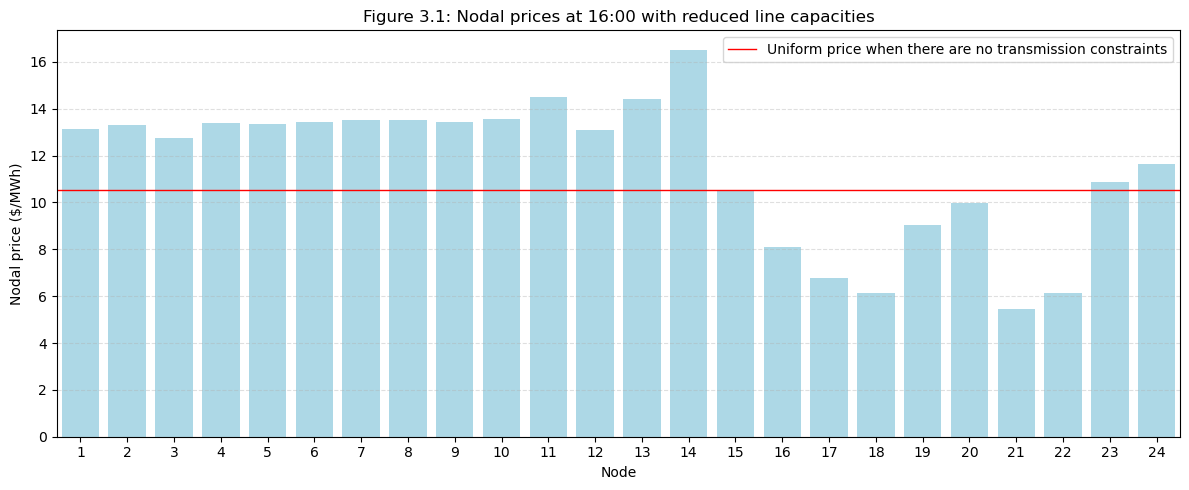

In [17]:
#-------------------------------
# Plotting Figure 3.1
#-------------------------------

ref_price = 10.52

nodes_sorted = sorted(nodal_price.keys())
prices_sorted = [nodal_price[n] for n in nodes_sorted]

plt.figure(figsize=(12, 5))
plt.bar(nodes_sorted, prices_sorted, color="lightblue")          # column graph
plt.axhline(ref_price, linewidth=1, color="red",
            label="Uniform price when there are no transmission constraints")  # horizontal line at 10.52

plt.xlabel("Node")
plt.ylabel("Nodal price ($/MWh)")
plt.title("Figure 3.1: Nodal prices at 16:00 with reduced line capacities")
plt.xticks(nodes_sorted)                     # show all node ticks (1..24)
plt.xlim(min(nodes_sorted) - 0.5, max(nodes_sorted) + 0.5)  # remove gaps at edges
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

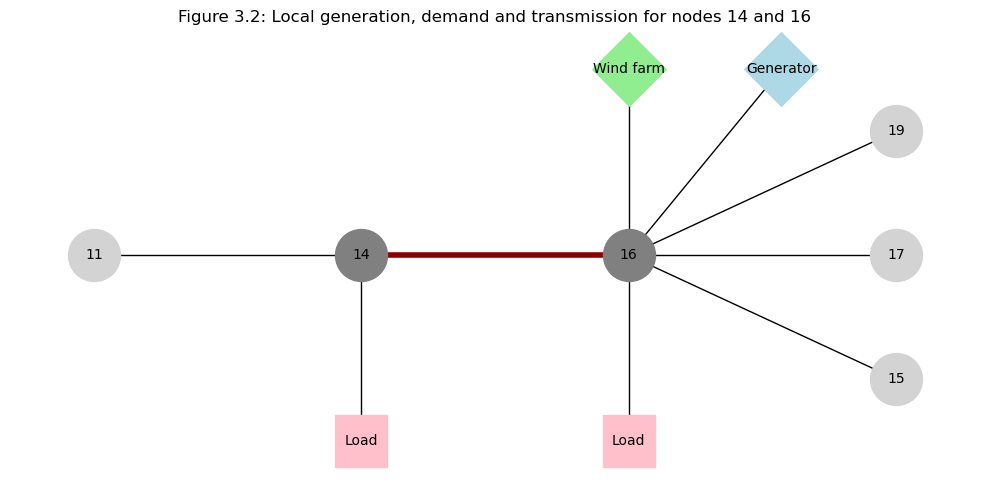

In [18]:
### 
import networkx as nx

# ----------------------------
# Figure 3.2: Local actor map
# ----------------------------
G = nx.Graph()

# Core buses
buses = ["16", "14", "11", "15", "17", "19"]
G.add_nodes_from(buses)

# Connections you specified
edges = [
    ("16", "19"),
    ("16", "17"),
    ("16", "15"),
    ("16", "14"),
    ("14", "11"),
]
G.add_edges_from(edges)

# "Actors" (loads / generators) as separate nodes connected to their bus
actors = [
    ("Load_16", "16"),
    ("Wind_16", "16"),
    ("Gen_16",  "16"),   # traditional generator
    ("Load_14", "14"),
]
for a, b in actors:
    G.add_node(a)
    G.add_edge(a, b)

# Manual positions for a clean schematic (edit if you want different spacing)
pos = {
    "16": (0.0, 0.0),
    "19": (1.4, 0.8),
    "17": (1.4, 0.0),
    "15": (1.4, -0.8),
    "14": (-1.4, 0.0),
    "11": (-2.8, 0.0),

    # Actors around bus 16
    "Wind_16": (0.0, 1.2),
    "Gen_16":  (0.8, 1.2),
    "Load_16": (0.0, -1.2),

    # Actors around bus 14 and 11
    "Load_14": (-1.4, -1.2),
}

# Node styling by type
bus_nodes   = buses
load_nodes  = [n for n in G.nodes if n.startswith("Load")]
wind_nodes  = [n for n in G.nodes if n.startswith("Wind")]
gen_nodes   = [n for n in G.nodes if n.startswith("Gen")]

plt.figure(figsize=(10, 5))

# Draw edges (lines)
nx.draw_networkx_edges(G, pos, width=1)

# Draw nodes with different shapes/colors (no special colors required; matplotlib defaults are fine)
nx.draw_networkx_nodes(G, pos, nodelist= ["14","16"],  node_size=1400, node_shape="o", node_color="gray")
nx.draw_networkx_nodes(G, pos, nodelist=["11","15","17","19"],  node_size=1400, node_shape="o", node_color="lightgray")
nx.draw_networkx_nodes(G, pos, nodelist=load_nodes, node_size=1400,  node_shape="s", node_color="pink")
nx.draw_networkx_nodes(G, pos, nodelist=wind_nodes, node_size=1400,  node_shape="D", node_color="lightgreen")
nx.draw_networkx_nodes(G, pos, nodelist=gen_nodes,  node_size=1400,  node_shape="D", node_color="lightblue")

# Labels: buses as just numbers, actors as readable tags
labels = {n: n for n in bus_nodes}
labels.update({
    "Load_16": "Load",
    "Wind_16": "Wind farm",
    "Gen_16":  "Generator",
    "Load_14": "Load",
})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

# Optional: highlight the congested line (16-14)
# If you want to visually emphasize it, uncomment the next lines:
nx.draw_networkx_edges(G, pos, edgelist=[("16", "14")], width=4, edge_color="darkred")

plt.title("Figure 3.2: Local generation, demand and transmission for nodes 14 and 16")
plt.axis("off")
plt.tight_layout()
plt.show()

# Optional: save for your report
# plt.savefig("Figure_3_2_actor_map_14_16.png", dpi=300, bbox_inches="tight")

In [19]:
##### ZONES ######
zonal_model = gp.Model("Zonal_Optimization_Step_3")

### Add production and consumption variables ###
z_production_variables = {g.unit_id: zonal_model.addVar(lb = 0, ub = float('inf'), vtype=GRB.CONTINUOUS, name = f"p_g_{g.unit_id}") for g in generators}
z_consumption_variables = {c.load_id: zonal_model.addVar(lb = 0, ub = consumer_demands_16[c.load_id], vtype=GRB.CONTINUOUS, name = f"p_d_{c.load_id}") for c in consumers}

### Add Transmission variables and constraints for zonal model ###
f_ab = zonal_model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name="f_ab") # flow from zone A to B

# ATC is the avaliable transfer capacity - set to the addition of capacities of lines (3,24), (9,11) and (10,12)
#inter_zone_lines = {(3, 24), (9, 11), (10, 12)}

#ATC = sum(
#    cap for (i, j, cap) in LINES
#    if (i, j) in inter_zone_lines or (j, i) in inter_zone_lines
#)

ATC = 500 # Creates congestion

print(f"ATC for flow between zones A and B: {ATC} MW")

# Add constraints to limit flow between zones A and B to the ATC
zonal_model.addConstr(f_ab <= ATC, name="ATC_pos")
zonal_model.addConstr(f_ab >= -ATC, name="ATC_neg")

### Power balance constraints for each zone ###
# Zone A: Nodes 1-10, Zone B: Nodes 11-24
zone_a_nodes = set(range(1, 11))
zone_b_nodes = set(range(11, 25))
# Power balance for Zone A
zonal_model.addConstr(
    gp.quicksum(-z_production_variables[g.unit_id] for g in generators if g.node in zone_a_nodes)
    + gp.quicksum(z_consumption_variables[c.load_id] for c in consumers if c.node in zone_a_nodes)
    + f_ab == 0,
    name="power_balance_zone_a"
)
# Power balance for Zone B
zonal_model.addConstr(
    gp.quicksum(-z_production_variables[g.unit_id] for g in generators if g.node in zone_b_nodes)
    + gp.quicksum(z_consumption_variables[c.load_id] for c in consumers if c.node in zone_b_nodes)
    - f_ab == 0,
    name="power_balance_zone_b"
)

### Generator capacity constraints ###
for g in generators:
    zonal_model.addConstr(z_production_variables[g.unit_id] <= g.p_max, name=f"cap_g{g.unit_id}")
## Demand constraints are already handled by the upper bounds on consumption variables

### Objective function: maximize social welfare ###
zonal_model.setObjective(
    gp.quicksum(demand_bids[d.load_id] * z_consumption_variables[d.load_id] for d in consumers)
    - gp.quicksum(g.cost_energy * z_production_variables[g.unit_id] for g in generators),
    GRB.MAXIMIZE
)

zonal_model.optimize()

ATC for flow between zones A and B: 500 MW
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 25.3.0 25D2128)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 22 rows, 36 columns and 57 nonzeros (Max)
Model fingerprint: 0xd7e06aeb
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 3e+02]
  Bounds range     [6e+01, 3e+02]
  RHS range        [6e+01, 6e+02]

Presolve removed 20 rows and 24 columns
Presolve time: 0.00s
Presolved: 2 rows, 12 columns, 13 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.5275953e+05   1.270130e+02   0.000000e+00      0s
       2    5.4628491e+05   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.01 seconds (0.00 work units)
Optimal objective  5.462849073e+05


In [20]:
# Check status and print results
if zonal_model.status == GRB.OPTIMAL:
    optimal_objective_zonal = zonal_model.objVal
    optimal_production_zonal = [z_production_variables[g.unit_id].x for g in generators]
    optimal_consumption_zonal = [z_consumption_variables[c.load_id].x for c in consumers]
    flow_ab = f_ab.x
    
    print(f"Optimal objective value (Social Welfare) for zonal model: {optimal_objective_zonal}")
    print(f"Flow from Zone A to B (f_ab): {flow_ab} MW")
    # print prices for each zone (shadow prices of power balance constraints)
    pi_zone_a = zonal_model.getConstrByName("power_balance_zone_a").Pi
    pi_zone_b = zonal_model.getConstrByName("power_balance_zone_b").Pi
    print(f"Zonal price in Zone A: {pi_zone_a} $/MWh")
    print(f"Zonal price in Zone B: {pi_zone_b} $/MWh")

Optimal objective value (Social Welfare) for zonal model: 546284.907342
Flow from Zone A to B (f_ab): -500.0 MW
Zonal price in Zone A: 13.32 $/MWh
Zonal price in Zone B: 10.52 $/MWh


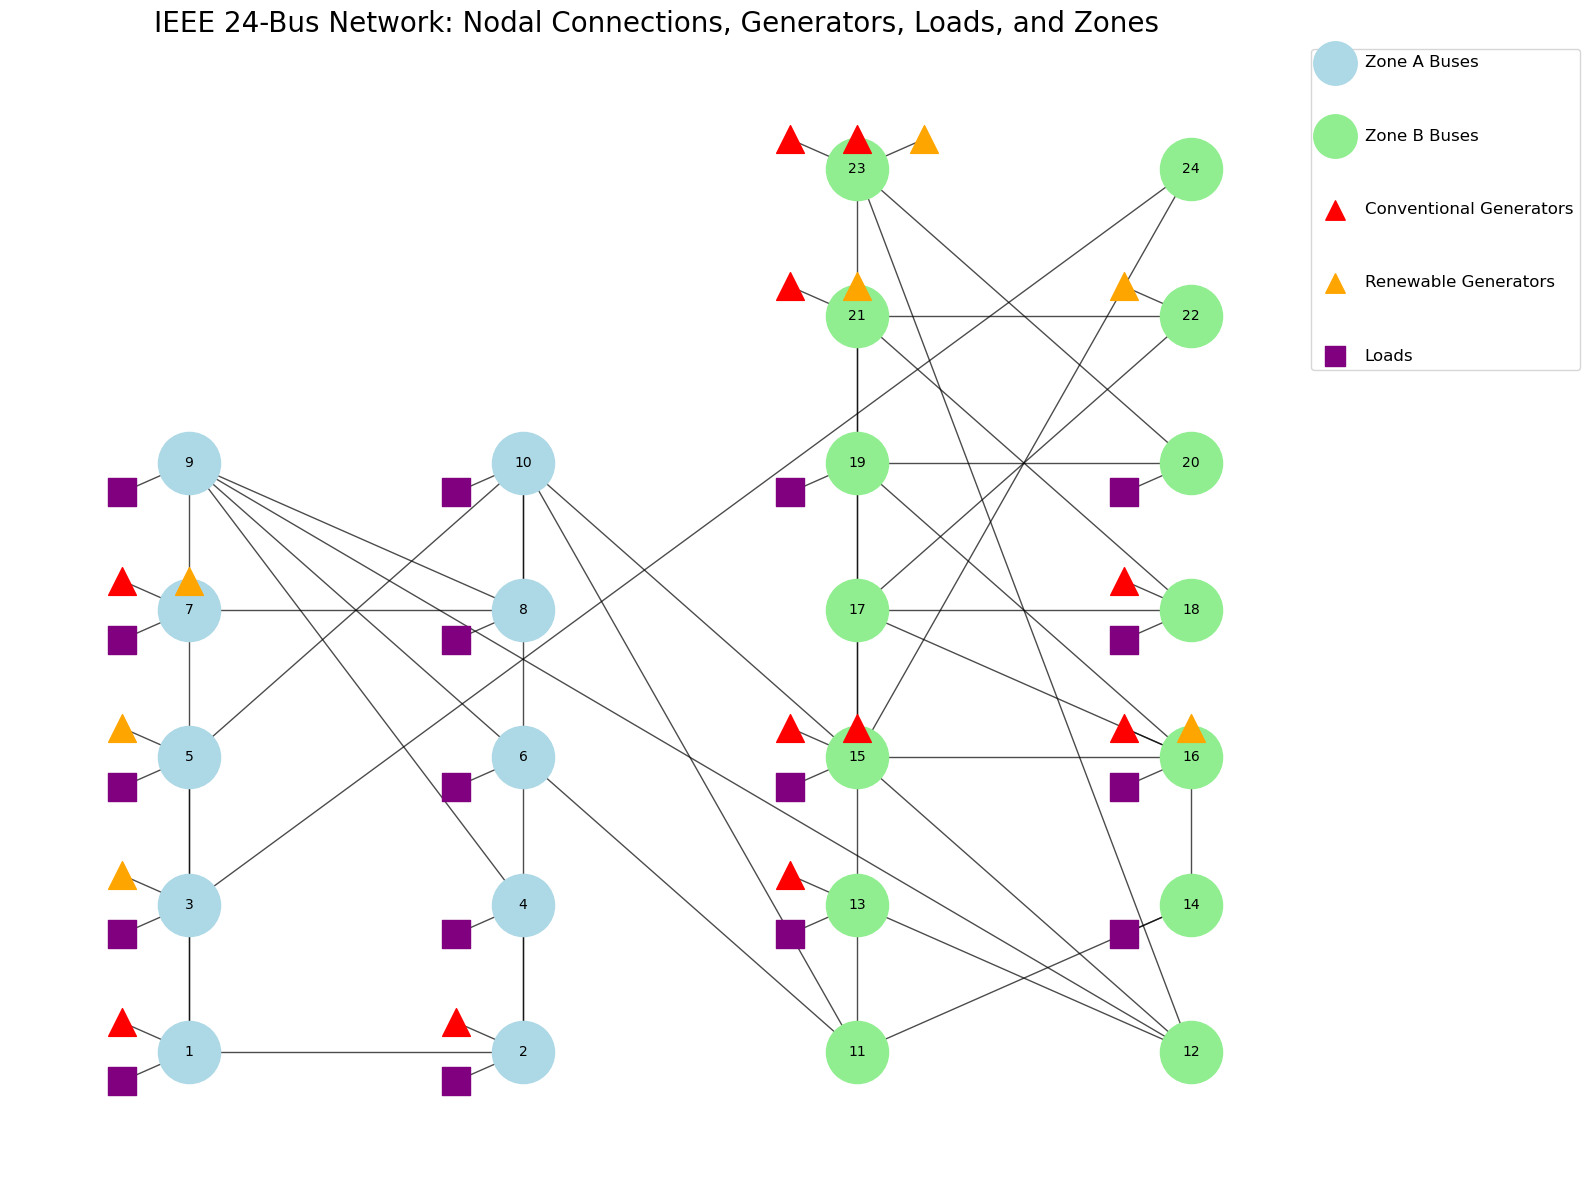

In [21]:
# Create the full network graph
G = nx.Graph()

# All nodes 1-24
nodes = list(range(1, 25))
G.add_nodes_from(nodes)

# Add edges from LINES
G.add_edges_from((i, j) for i, j, cap in LINES)

# Define zones
zone_a_nodes = set(range(1, 11))  # 1-10
zone_b_nodes = set(range(11, 25))  # 11-24

# Add actor nodes for generators and loads
for g in generators:
    actor = f"G{g.unit_id}"
    G.add_node(actor)
    G.add_edge(actor, g.node)

for c in consumers:
    actor = f"L{c.load_id}"
    G.add_node(actor)
    G.add_edge(actor, c.node)

# Positions: Zone A on left (cols 0-1), Zone B on right (cols 2-3)
pos = {}
# Zone A: 10 nodes, 5 rows x 2 cols
sorted_a = sorted(zone_a_nodes)
for idx, node in enumerate(sorted_a):
    row = idx // 2
    col = idx % 2
    pos[node] = (col, row)

# Zone B: 14 nodes, 7 rows x 2 cols
sorted_b = sorted(zone_b_nodes)
for idx, node in enumerate(sorted_b):
    row = idx // 2
    col = 2 + idx % 2
    pos[node] = (col, row)

# Position actors around their buses
for node in nodes:
    gens_at_node = [g for g in generators if g.node == node]
    loads_at_node = [c for c in consumers if c.node == node]
    
    # Position generators above and to the right
    for i, g in enumerate(gens_at_node):
        offset_x = 0.2 * ((i % 3) - 1)  # -0.15, 0, 0.15
        offset_y = 0.2 * (1 + i // 3)
        pos[f"G{g.unit_id}"] = (pos[node][0] + offset_x, pos[node][1] + offset_y)
    
    # Position loads below and to the left
    for i, c in enumerate(loads_at_node):
        offset_x = -0.2 * (1 + i // 3)
        offset_y = -0.2 * ((i % 3) + 1)
        pos[f"L{c.load_id}"] = (pos[node][0] + offset_x, pos[node][1] + offset_y)

plt.figure(figsize=(16, 12))

# Draw edges
nx.draw_networkx_edges(G, pos, width=1, alpha=0.7)

# Draw bus nodes by zone
nx.draw_networkx_nodes(G, pos, nodelist=list(zone_a_nodes), node_size=2000, node_color="lightblue", label="Zone A Buses")
nx.draw_networkx_nodes(G, pos, nodelist=list(zone_b_nodes), node_size=2000, node_color="lightgreen", label="Zone B Buses")

# Draw generator actors
gen_actors = [f"G{g.unit_id}" for g in generators]
conventional_actors = [f"G{g.unit_id}" for g in generators if g.cost_energy > 0]
renewable_actors = [f"G{g.unit_id}" for g in generators if g.cost_energy == 0]
nx.draw_networkx_nodes(G, pos, nodelist=conventional_actors, node_size=400, node_shape="^", node_color="red", label="Conventional Generators")
nx.draw_networkx_nodes(G, pos, nodelist=renewable_actors, node_size=400, node_shape="^", node_color="orange", label="Renewable Generators")

# Draw load actors
load_actors = [f"L{c.load_id}" for c in consumers]
nx.draw_networkx_nodes(G, pos, nodelist=load_actors, node_size=400, node_shape="s", node_color="purple", label="Loads")

# Labels for bus nodes
labels = {node: str(node) for node in nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title("IEEE 24-Bus Network: Nodal Connections, Generators, Loads, and Zones", fontsize=20)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), labelspacing=3.5, markerscale=0.7, fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

In [22]:
# Generator profits in zonal model
zonal_generator_profits = {}
for g in generators:
    price = zonal_model.getConstrByName(f"power_balance_zone_a").Pi if g.node in zone_a_nodes else zonal_model.getConstrByName(f"power_balance_zone_b").Pi
    cost = g.cost_energy
    profit = (price - cost) * z_production_variables[g.unit_id].x
    zonal_generator_profits[g.unit_id] = profit
    print(f"Generator {g.unit_id} at node {g.node}: Profit = {profit:.2f} $")

Generator 1 at node 1: Profit = 0.00 $
Generator 2 at node 2: Profit = 0.00 $
Generator 3 at node 7: Profit = -0.00 $
Generator 4 at node 13: Profit = -0.00 $
Generator 5 at node 15: Profit = -0.00 $
Generator 6 at node 15: Profit = 0.00 $
Generator 7 at node 16: Profit = 0.00 $
Generator 8 at node 18: Profit = 1800.00 $
Generator 9 at node 21: Profit = 2020.00 $
Generator 10 at node 22: Profit = 3156.00 $
Generator 11 at node 23: Profit = 0.00 $
Generator 12 at node 23: Profit = -0.00 $
Generator 13 at node 3: Profit = 2664.00 $
Generator 14 at node 5: Profit = 2664.00 $
Generator 15 at node 7: Profit = 2664.00 $
Generator 16 at node 16: Profit = 2104.00 $
Generator 17 at node 21: Profit = 2104.00 $
Generator 18 at node 23: Profit = 2104.00 $


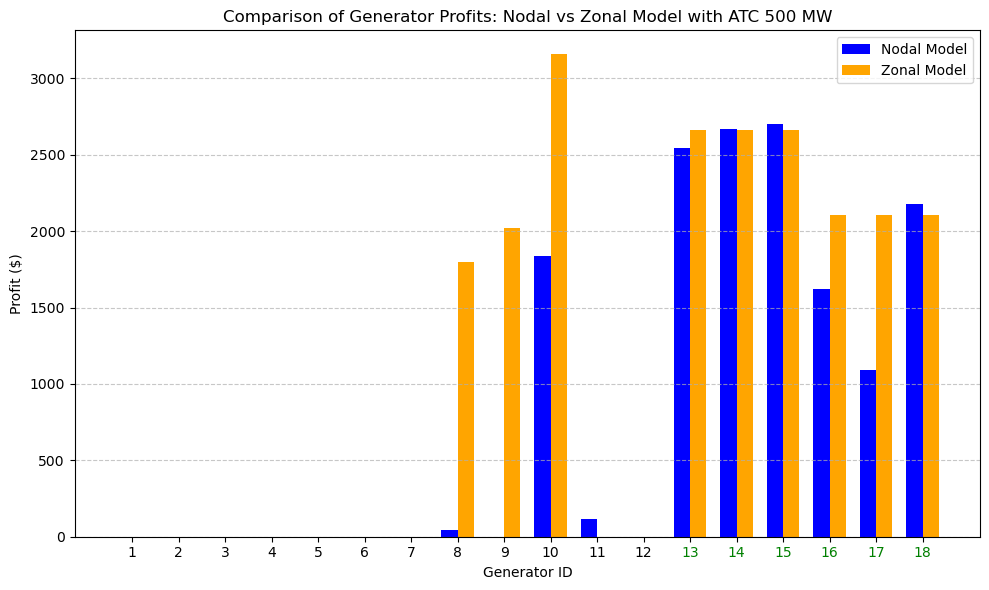

In [23]:
# Plot generator profits in zonal model vs nodal model
plt.figure(figsize=(10, 6)) 
generator_ids = [g.unit_id for g in generators]
profits_nodal = [generator_profits[g.unit_id] for g in generators]
profits_zonal = [zonal_generator_profits[g.unit_id] for g in generators]
x = np.arange(len(generator_ids))
width = 0.35
plt.bar(x - width/2, profits_nodal, width, label="Nodal Model", color="blue")
plt.bar(x + width/2, profits_zonal, width, label="Zonal Model", color="orange")
plt.xlabel("Generator ID")
plt.ylabel("Profit ($)")
plt.title(f"Comparison of Generator Profits: Nodal vs Zonal Model with ATC {ATC} MW")
plt.xticks(x, generator_ids)

for label in plt.gca().get_xticklabels():
    gen = int(label.get_text())
    if 13 <= gen <= 18:
        label.set_color("green")
    else:
        label.set_color("black")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()